1. Introduction

# Titanic Dataset - Exploratory Data Analysis

## Objective
To analyze passenger data and identify factors affecting survival.

## Dataset
Titanic dataset from Kaggle.

In [1]:
#Import and Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv(r"D:\Rahis\Rahi\learnings\AI_ML_PROJECT\titanic\train.csv")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
#Data Overview

df.shape

(891, 12)

In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

- Dataset contains 891 rows and 12 columns
- Missing values in Age, Cabin, Embarked

In [10]:
#4. Data Cleaning

df["Age"] = df["Age"].fillna(df["Age"].mean())

In [11]:
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace = True)

C:\Users\Jainam\AppData\Local\Temp\ipykernel_5748\1971420511.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0], inplace = True)


In [12]:
df.drop("Cabin", axis = 1, inplace= True)

- Filled Age with mean
- Filled Embarked with mode
- Dropped Cabin due to excessive missing values

In [13]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [14]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [15]:
df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [16]:
df["Age"].describe()

count    891.000000
mean      29.699118
std       13.002015
min        0.420000
25%       22.000000
50%       29.699118
75%       35.000000
max       80.000000
Name: Age, dtype: float64

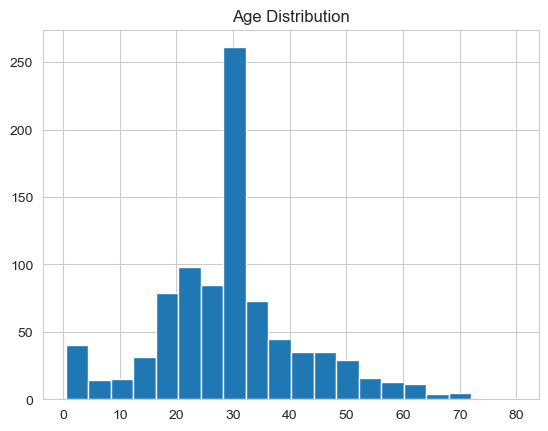

In [17]:
#5. Univariate Analysis


plt.hist(df["Age"], bins = 20)
plt.title("Age Distribution")
plt.show()

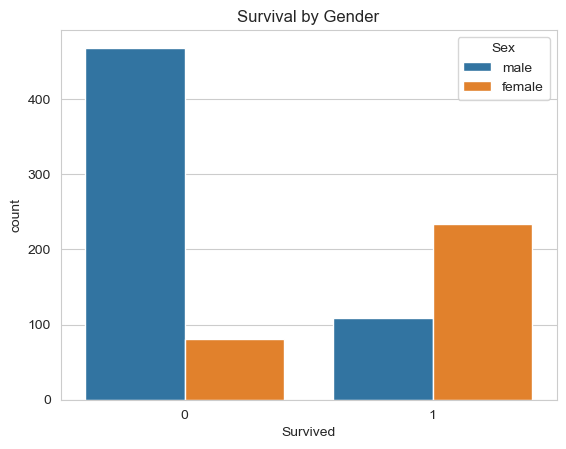

In [18]:
#6. Bivariate Analysis


sns.countplot(x= "Survived" , hue = "Sex", data = df)
plt.title("Survival by Gender")
plt.show()

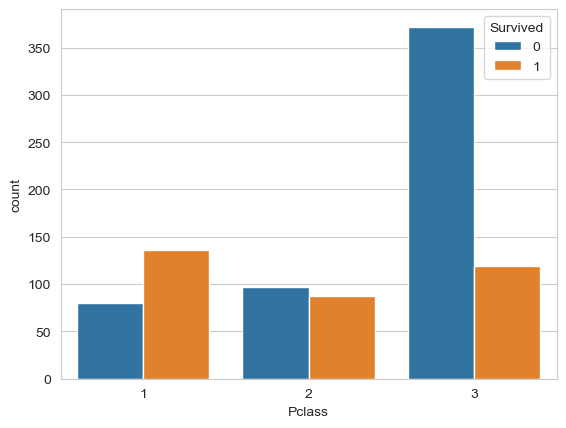

In [19]:
sns.countplot(x = "Pclass" ,  hue = "Survived" , data = df)
plt.show()

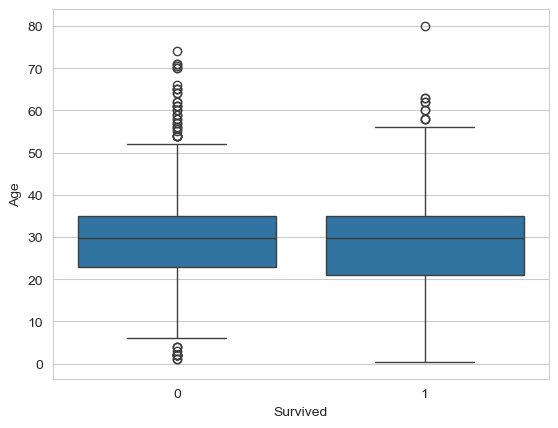

In [20]:
sns.boxplot(x = "Survived" , y = "Age" ,  data = df)
plt.show()

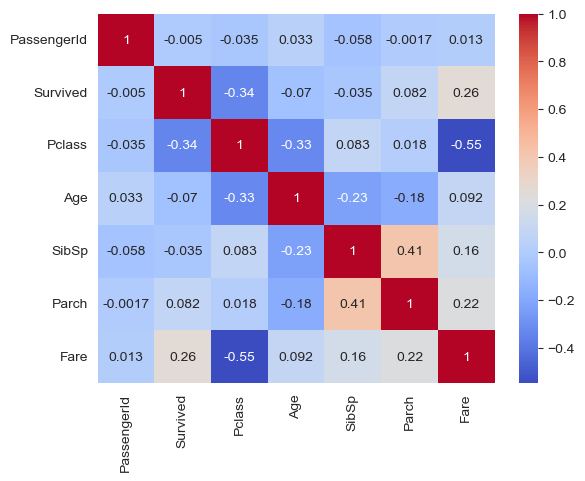

In [21]:
#7. Correlation Analysis

corr = df.corr(numeric_only = True )

sns.heatmap(corr, annot = True, cmap = "coolwarm")
plt.show()

8. Key Insights

⭐ Insight 1 — Gender Survival Gap (Huge)

Female survival rate is significantly higher than male survival rate, indicating priority evacuation policies like "women first".

⭐ Insight 2 — Class = Survival Power

First-class passengers had a much higher survival probability, showing strong socio-economic influence on survival.

⭐ Insight 3 — Wealth Matters

Higher fare passengers were more likely to survive, reinforcing that wealth influenced access to safety.

⭐ Insight 4 — Age Alone is NOT Strong Predictor

Age does not show a strong direct correlation with survival, unlike gender and class.

⭐ Insight 5 — Third Class Was Most Vulnerable

Majority of passengers were in 3rd class and had the lowest survival rate, making them the most vulnerable group.

Survival depended heavily on gender, class, and socio-economic factors.